# Sentiment-Returns Analysis

Analyzing the relationship between FinBERT sentiment and stock returns to evaluate trading strategy viability.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('..')

from src.analysis import (
    returns_by_sentiment,
    statistical_tests,
    cumulative_returns,
    plot_returns_distribution,
    plot_cumulative_returns,
    plot_returns_by_horizon,
    plot_returns_by_confidence
)

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

## 1. Load Data

In [2]:
df = pd.read_parquet('../data/intermediate/events_with_sentiment.parquet')
print(f"Loaded {len(df):,} events")
print(f"\nDate range: {df['entry_date'].min()} to {df['entry_date'].max()}")
print(f"\nSentiment distribution:")
print(df['sentiment'].value_counts())

Loaded 1,058,672 events

Date range: 2015-01-02 00:00:00 to 2020-06-12 00:00:00

Sentiment distribution:
sentiment
neutral     503606
negative    280627
positive    274439
Name: count, dtype: int64


In [17]:
neg = df[df["sentiment"] == "positive"]

neg.head(10)

,ticker,headline,published_utc,published_et,entry_date,horizon,exit_date,entry_close,exit_close,spy_entry,spy_exit,ret,spy_ret,excess_ret,sentiment,confidence
4,A,B of A Securities Maintains Neutral on Agilent...,2020-05-22 15:38:00+00:00,2020-05-22 11:38:00-04:00,2020-05-26,1,2020-05-27,82.780731,82.828804,275.677582,279.779388,0.000581,0.014879,-0.014298,positive,0.662541
5,A,"CFRA Maintains Hold on Agilent Technologies, L...",2020-05-22 15:23:00+00:00,2020-05-22 11:23:00-04:00,2020-05-26,1,2020-05-27,82.780731,82.828804,275.677582,279.779388,0.000581,0.014879,-0.014298,positive,0.448215
6,A,"UBS Maintains Neutral on Agilent Technologies,...",2020-05-22 13:36:00+00:00,2020-05-22 09:36:00-04:00,2020-05-26,1,2020-05-27,82.780731,82.828804,275.677582,279.779388,0.000581,0.014879,-0.014298,positive,0.866881
7,A,Agilent Technologies shares are trading higher...,2020-05-22 13:07:00+00:00,2020-05-22 09:07:00-04:00,2020-05-26,1,2020-05-27,82.780731,82.828804,275.677582,279.779388,0.000581,0.014879,-0.014298,positive,0.956582
8,A,Wells Fargo Maintains Overweight on Agilent Te...,2020-05-22 12:37:00+00:00,2020-05-22 08:37:00-04:00,2020-05-26,1,2020-05-27,82.780731,82.828804,275.677582,279.779388,0.000581,0.014879,-0.014298,positive,0.929890
11,A,SVB Leerink Maintains Outperform on Agilent Te...,2020-05-22 09:14:00+00:00,2020-05-22 05:14:00-04:00,2020-05-26,1,2020-05-27,82.780731,82.828804,275.677582,279.779388,0.000581,0.014879,-0.014298,positive,0.939257
13,A,Agilent Technologies shares are trading higher...,2020-05-21 20:21:00+00:00,2020-05-21 16:21:00-04:00,2020-05-22,1,2020-05-26,81.675468,82.780731,272.322449,275.677582,0.013532,0.012320,0.001212,positive,0.956582
14,A,Agilent Technologies Q2 Adj. EPS $0.71 Beats $...,2020-05-21 20:06:00+00:00,2020-05-21 16:06:00-04:00,2020-05-22,1,2020-05-26,81.675468,82.780731,272.322449,275.677582,0.013532,0.012320,0.001212,positive,0.775243
16,A,Agilent Technologies Receives FDA Approval for...,2020-05-18 12:10:00+00:00,2020-05-18 08:10:00-04:00,2020-05-19,1,2020-05-20,78.782501,78.532608,269.123901,273.695862,-0.003172,0.016988,-0.020160,positive,0.860116
18,A,Pershing Square 13F Shows Fund Raises Stake In...,2020-05-15 20:39:00+00:00,2020-05-15 16:39:00-04:00,2020-05-18,1,2020-05-19,80.406776,78.782501,271.916840,269.123901,-0.020201,-0.010271,-0.009929,positive,0.557799


## 2. Returns by Sentiment

Do positive sentiment headlines lead to higher returns?

In [4]:
# Excess returns (vs SPY)
stats_excess = returns_by_sentiment(df, 'excess_ret')
print("Excess Returns by Sentiment:")
print(stats_excess.round(6))

Excess Returns by Sentiment:
               mean    median       std   count        se
sentiment                                                
positive   0.001818 -0.000678  0.776443  274439  0.001482
neutral    0.001766 -0.000649  0.609844  503606  0.000859
negative   0.003051 -0.000892  0.841426  280627  0.001588


In [5]:
# Raw returns
stats_raw = returns_by_sentiment(df, 'ret')
print("Raw Returns by Sentiment:")
print(stats_raw.round(6))

Raw Returns by Sentiment:
               mean    median       std   count        se
sentiment                                                
positive   0.003144  0.000528  0.776811  274439  0.001483
neutral    0.002771  0.000404  0.610343  503606  0.000860
negative   0.002433  0.000000  0.842285  280627  0.001590


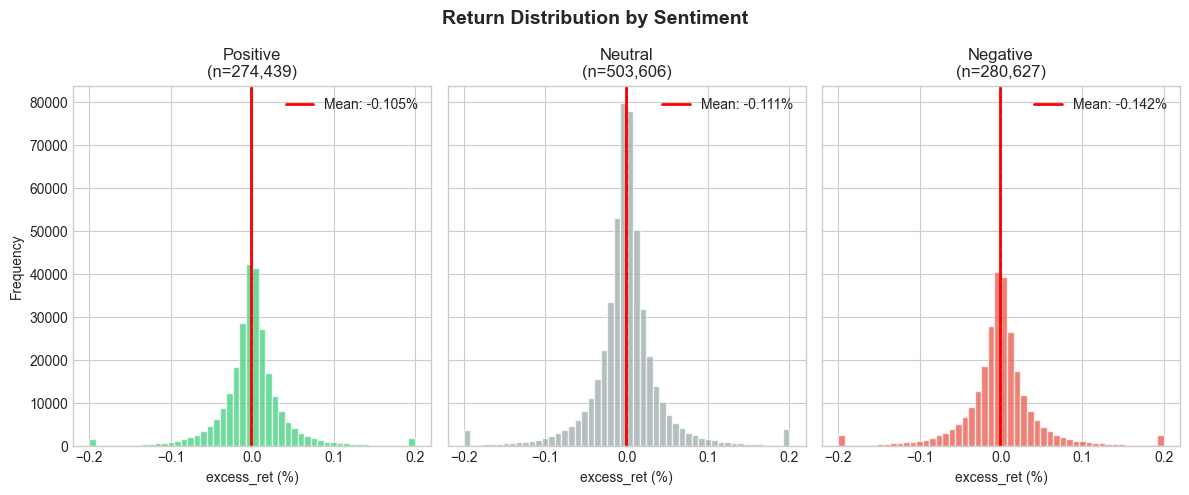

In [6]:
# Visualize return distributions
fig = plot_returns_distribution(df, 'excess_ret')
plt.show()

## 3. Statistical Significance

Are the differences between sentiment groups statistically significant?

In [7]:
tests = statistical_tests(df, 'excess_ret')

for comparison, results in tests.items():
    print(f"\n{comparison.upper()}")
    print(f"  Mean difference: {results['mean_diff']*100:.4f}%")
    print(f"  t-statistic: {results['t_statistic']:.4f}")
    print(f"  p-value: {results['p_value']:.2e}")
    print(f"  Significant (p<0.05): {'✓ Yes' if results['significant'] else '✗ No'}")


POSITIVE_VS_NEGATIVE
  Mean difference: -0.1234%
  t-statistic: -0.5674
  p-value: 5.70e-01
  Significant (p<0.05): ✗ No

POSITIVE_VS_NEUTRAL
  Mean difference: 0.0051%
  t-statistic: 0.0322
  p-value: 9.74e-01
  Significant (p<0.05): ✗ No

NEGATIVE_VS_NEUTRAL
  Mean difference: 0.1285%
  t-statistic: 0.7776
  p-value: 4.37e-01
  Significant (p<0.05): ✗ No


## 4. Returns by Holding Period

Compare 1-day vs 5-day holding periods.

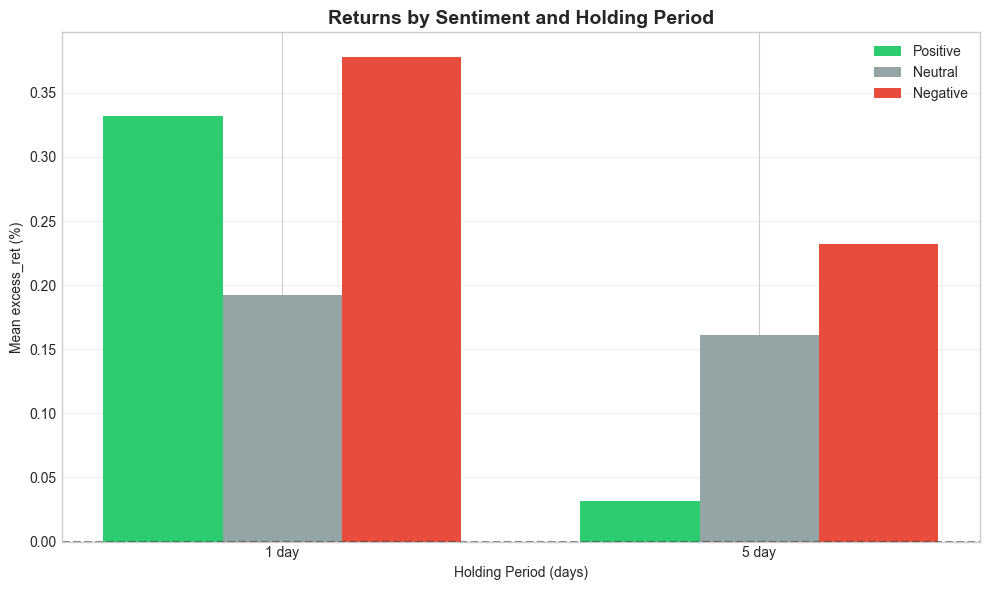

In [8]:
fig = plot_returns_by_horizon(df, 'excess_ret')
plt.show()

In [9]:
# Detailed stats by horizon
for horizon in df['horizon'].unique():
    print(f"\n=== {horizon}-Day Horizon ===")
    print(returns_by_sentiment(df[df['horizon'] == horizon], 'excess_ret').round(6))


=== 1-Day Horizon ===
               mean    median       std   count        se
sentiment                                                
positive   0.003320 -0.000402  1.018685  137251  0.002750
neutral    0.001921 -0.000410  0.635721  251884  0.001267
negative   0.003783 -0.000528  0.926536  140478  0.002472

=== 5-Day Horizon ===
               mean    median       std   count        se
sentiment                                                
positive   0.000314 -0.001357  0.409645  137188  0.001106
neutral    0.001611 -0.001239  0.582802  251722  0.001162
negative   0.002318 -0.001702  0.746443  140149  0.001994


## 5. Confidence Analysis

Do high-confidence predictions perform better?

c:\Users\Jeet\Documents\Projects\Sentiment-Analysis-for-PEAD\notebooks\..\src\analysis.py:235: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df.groupby(["conf_bin", "sentiment"])[return_col].mean().unstack()


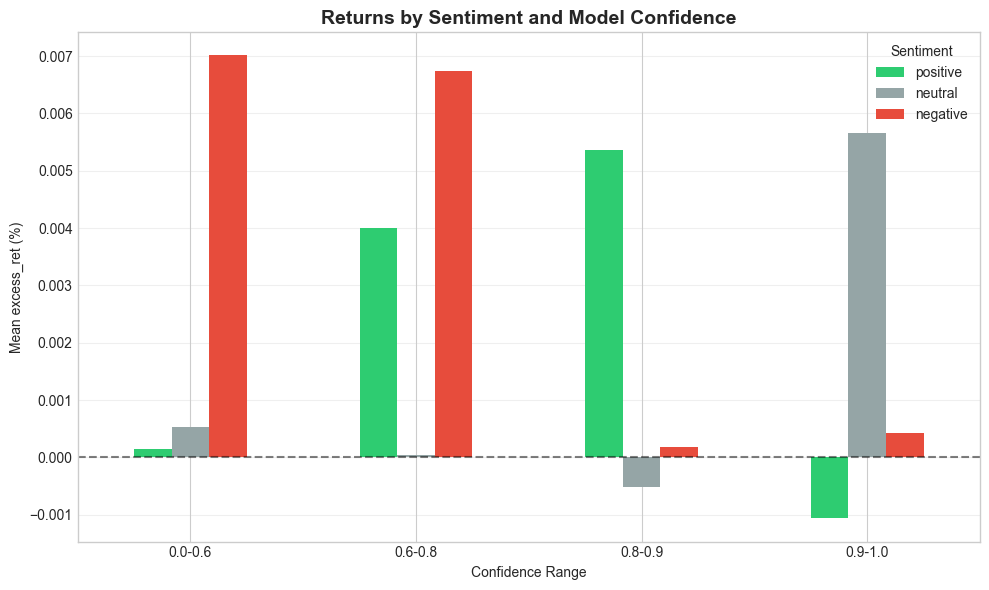

In [10]:
fig = plot_returns_by_confidence(df, 'excess_ret')
plt.show()

In [11]:
# High confidence only (>0.8)
high_conf = df[df['confidence'] > 0.8]
print(f"High confidence events (>0.8): {len(high_conf):,} ({len(high_conf)/len(df)*100:.1f}%)")
print("\nReturns for high-confidence predictions:")
print(returns_by_sentiment(high_conf, 'excess_ret').round(6))

High confidence events (>0.8): 639,822 (60.4%)

Returns for high-confidence predictions:
               mean    median       std   count        se
sentiment                                                
positive   0.001227 -0.000782  0.860145  163153  0.002129
neutral    0.002728 -0.000585  0.772535  311691  0.001384
negative   0.000374 -0.001020  0.520996  164978  0.001283


## 6. Cumulative Returns Backtest

Strategy: Long positive sentiment, Short negative sentiment.

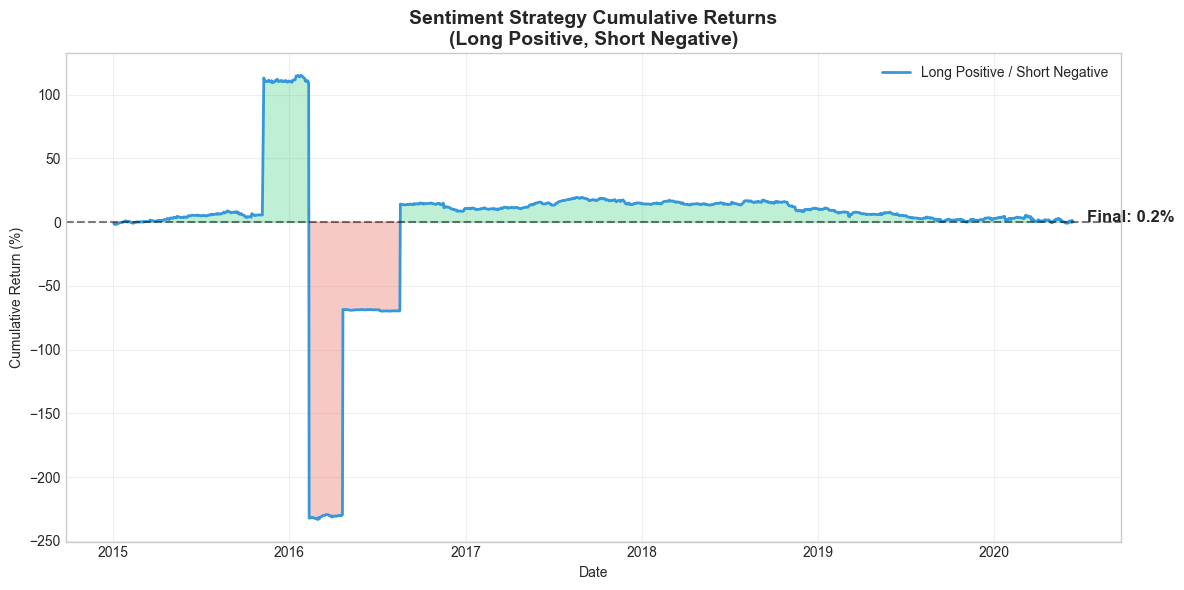

In [12]:
# Use 1-day horizon for faster turnover
df_1d = df[df['horizon'] == 1]

cum_ret = cumulative_returns(df_1d, 'excess_ret')
fig = plot_cumulative_returns(cum_ret)
plt.show()

In [13]:
# Strategy statistics
print("Strategy Performance Summary:")
print(f"  Total cumulative return: {cum_ret['cumulative_ret'].iloc[-1]*100:.2f}%")
print(f"  Mean daily return: {cum_ret['strategy_ret'].mean()*100:.4f}%")
print(f"  Std daily return: {cum_ret['strategy_ret'].std()*100:.4f}%")
print(f"  Sharpe ratio (annualized): {cum_ret['strategy_ret'].mean() / cum_ret['strategy_ret'].std() * np.sqrt(252):.2f}")
print(f"  Win rate: {(cum_ret['strategy_ret'] > 0).mean()*100:.1f}%")
print(f"  Trading days: {len(cum_ret)}")

Strategy Performance Summary:
  Total cumulative return: 0.24%
  Mean daily return: 0.0551%
  Std daily return: 9.6715%
  Sharpe ratio (annualized): 0.09
  Win rate: 49.4%
  Trading days: 1371


## 7. Summary & Conclusions

Key findings from the analysis:

In [14]:
print("="*60)
print("SUMMARY")
print("="*60)

stats = returns_by_sentiment(df, 'excess_ret')
pos_ret = stats.loc['positive', 'mean'] * 100
neg_ret = stats.loc['negative', 'mean'] * 100
spread = pos_ret - neg_ret

print(f"\n1. Mean Excess Returns:")
print(f"   Positive sentiment: {pos_ret:+.4f}%")
print(f"   Negative sentiment: {neg_ret:+.4f}%")
print(f"   Spread (pos - neg): {spread:+.4f}%")

tests = statistical_tests(df, 'excess_ret')
print(f"\n2. Statistical Significance:")
print(f"   Positive vs Negative: p={tests['positive_vs_negative']['p_value']:.2e}")

final_ret = cum_ret['cumulative_ret'].iloc[-1] * 100
sharpe = cum_ret['strategy_ret'].mean() / cum_ret['strategy_ret'].std() * np.sqrt(252)
print(f"\n3. Strategy Performance:")
print(f"   Cumulative return: {final_ret:+.2f}%")
print(f"   Sharpe ratio: {sharpe:.2f}")

print("\n" + "="*60)

SUMMARY

1. Mean Excess Returns:
   Positive sentiment: +0.1818%
   Negative sentiment: +0.3051%
   Spread (pos - neg): -0.1234%

2. Statistical Significance:
   Positive vs Negative: p=5.70e-01

3. Strategy Performance:
   Cumulative return: +0.24%
   Sharpe ratio: 0.09

